# Analyse Exploratoire des Ventes — Supermarché Q1 2019

**Stack :** Python · Pandas · Matplotlib · Seaborn · Jupyter Notebook

---

Pour ce projet, j'ai travaillé sur un dataset de ventes d'une chaîne de supermarchés
implantée dans 3 villes. L'idée de départ était simple : à partir de 1 000 transactions
enregistrées sur 3 mois, est-ce qu'on peut comprendre ce qui drive les ventes et
la satisfaction client ?

C'est le type d'analyse qu'on retrouve dans beaucoup d'entreprises — retail, e-commerce,
restauration — où on a des données de caisse mais pas toujours le réflexe de les exploiter.

**Ce que j'ai cherché à répondre :**

- Quelles catégories de produits génèrent le plus de chiffre d'affaires ?
- Est-ce qu'il y a des heures ou des périodes plus rentables que d'autres ?
- Le type de client (membre vs normal) influence-t-il le panier moyen ?
- Y a-t-il un lien entre la satisfaction client et le montant dépensé ?

**Démarche suivie :**

1. Chargement et exploration initiale des données
2. Nettoyage et préparation (types, colonnes dérivées)
3. Calcul des KPIs business clés
4. Analyse par dimension (catégorie, heure, branche, genre)
5. Visualisations et interprétation
6. Conclusions et recommandations actionnables

## Étape 1 — Import des librairies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Librairies importées avec succès")

Librairies importées avec succès


## Étape 2 — Chargement des données

On charge le CSV et on prépare les colonnes de date/heure.

In [4]:
df = pd.read_csv('supermarket_sales.csv', parse_dates=['Date'])
df['Hour'] = df['Time'].str[:2].astype(int)
df['Month'] = df['Date'].dt.month_name()
df['Month_num'] = df['Date'].dt.month

print(f"Shape : {df.shape}")
df.head()

Shape : (1000, 20)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin %,gross income,Rating,Hour,Month,Month_num
0,750-22-1895,Branche B,Mandalay,Member,Male,Food and beverages,88.47,9,38.22,834.45,2019-01-01 00:00:00.000000,15:33,Cash,796.23,4.8,38.22,5.6,15,January,1
1,750-23-3682,Branche A,Yangon,Member,Female,Home and lifestyle,29.61,8,13.03,249.91,2019-01-01 00:00:00.000000,14:52,Cash,236.88,5.5,13.03,7.2,14,January,1
2,750-64-8021,Branche A,Yangon,Normal,Female,Electronic accessories,89.18,2,8.03,186.39,2019-01-01 00:00:00.000000,15:17,Ewallet,178.36,4.5,8.03,7.5,15,January,1
3,750-22-4255,Branche B,Mandalay,Member,Male,Home and lifestyle,58.72,2,6.46,123.90,2019-01-01 04:16:34.594594,17:02,Credit card,117.44,5.5,6.46,5.8,17,January,1
4,750-40-4927,Branche C,Naypyitaw,Normal,Female,Electronic accessories,54.83,4,9.87,229.19,2019-01-01 06:24:51.891891,20:56,Ewallet,219.32,4.5,9.87,6.8,20,January,1


## Étape 3 — Exploration initiale (EDA)

Avant d'analyser, on **explore** la structure du dataset.

In [5]:
print(f"Dimensions    : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période       : {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Branches      : {df['Branch'].unique().tolist()}")
print(f"Catégories    : {df['Product line'].unique().tolist()}")
print()

missing = df.isnull().sum()
print("Valeurs manquantes :")
if missing.sum() == 0:
    print("  Aucune ")
else:
    print(missing[missing > 0])

print(f"\nDoublons : {df.duplicated().sum()}")

Dimensions    : 1,000 lignes × 20 colonnes
Période       : 2019-01-01 -> 2019-03-30
Branches      : ['Branche B', 'Branche A', 'Branche C']
Catégories    : ['Food and beverages', 'Home and lifestyle', 'Electronic accessories', 'Fashion accessories', 'Health and beauty', 'Sports and travel']

Valeurs manquantes :
  Aucune 

Doublons : 0


In [6]:
df[['Unit price', 'Quantity', 'Total', 'gross income', 'Rating']].describe().round(2)

,Unit price,Quantity,Total,gross income,Rating
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,54.47,5.56,316.58,15.84,7.06
std,25.81,2.87,231.23,11.72,1.74
min,10.00,1.00,12.15,0.61,4.00
25%,32.05,3.00,133.25,6.57,5.60
50%,54.52,5.50,259.88,12.96,7.10
75%,76.60,8.00,454.34,22.40,8.60
max,99.80,10.00,1037.13,57.61,10.00


## Étape 4 — KPIs Business

On calcule les métriques clés pour un aperçu rapide de la performance.

In [7]:
total_revenue  = df['Total'].sum()
total_profit   = df['gross income'].sum()
avg_basket     = df['Total'].mean()
avg_rating     = df['Rating'].mean()

print(f"CA total           : ${total_revenue:,.2f}")
print(f"Bénéfice brut      : ${total_profit:,.2f}")
print(f"Panier moyen       : ${avg_basket:.2f}")
print(f"Note moyenne       : {avg_rating:.2f} / 10")
print(f"Nb transactions    : {len(df):,}")

CA total           : $316,579.21
Bénéfice brut      : $15,837.39
Panier moyen       : $316.58
Note moyenne       : 7.06 / 10
Nb transactions    : 1,000


In [8]:
df.groupby('Branch')['Total'].agg(
    CA_total='sum',
    Panier_moyen='mean',
    Nb_transactions='count'
).round(2).sort_values('CA_total', ascending=False)

,CA_total,Panier_moyen,Nb_transactions
Branch,,,
Branche A,115491.81,316.42,365
Branche B,104408.86,316.39,330
Branche C,96678.54,316.98,305


## Étape 5 — Visualisations

On crée 4 graphiques complémentaires pour raconter une histoire avec les données.

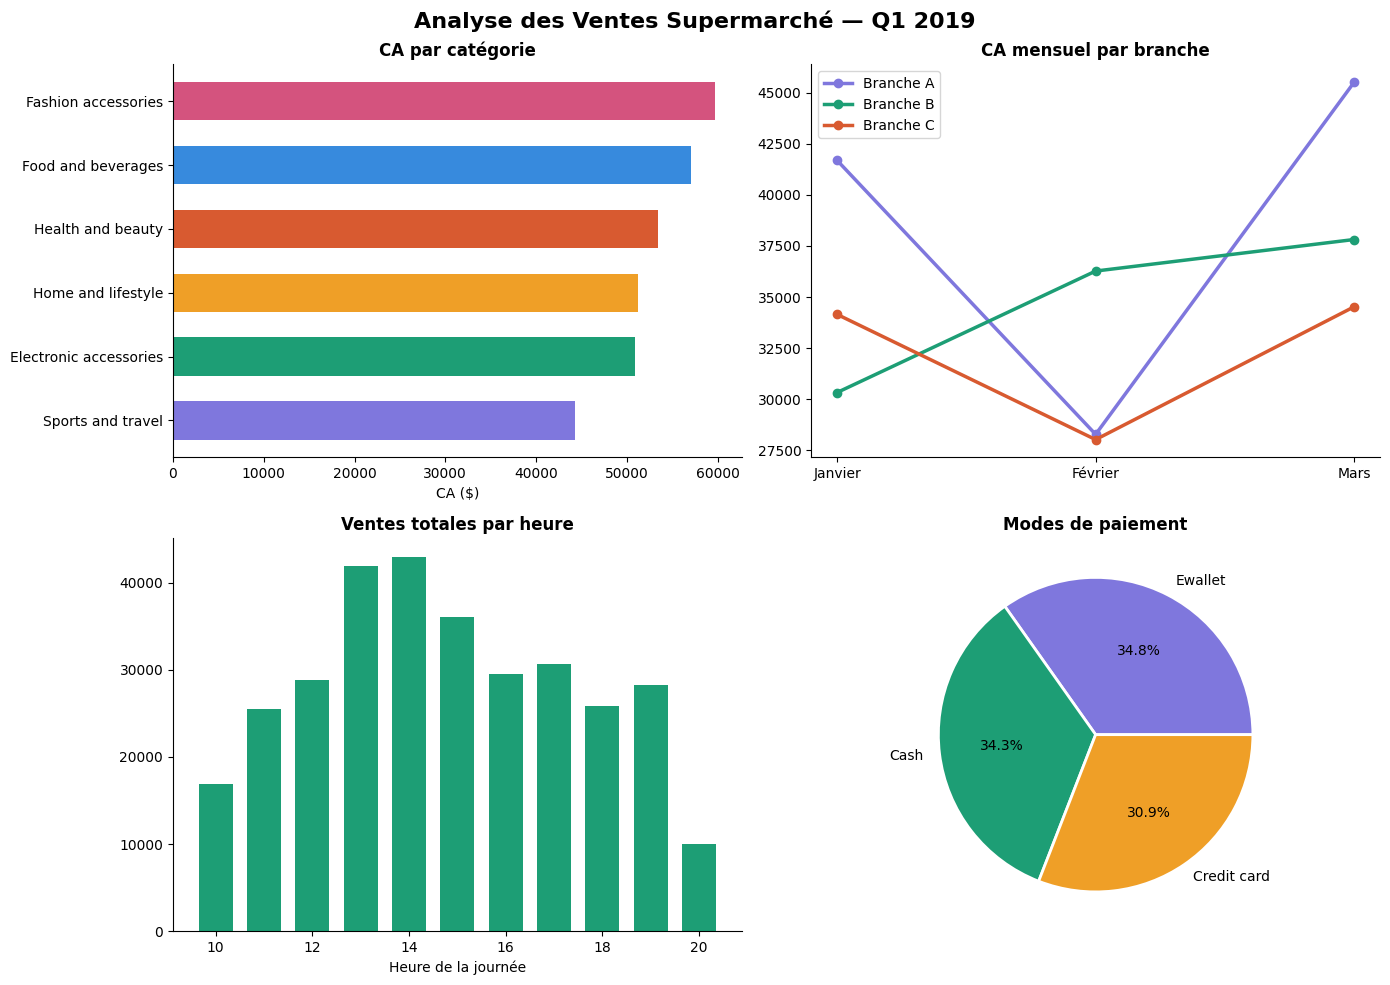

In [9]:
colors_cat = ['#7F77DD','#1D9E75','#EF9F27','#D85A30','#378ADD','#D4537E']
colors_branches = {'Branche A':'#7F77DD','Branche B':'#1D9E75','Branche C':'#D85A30'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse des Ventes Supermarché — Q1 2019', fontsize=16, fontweight='bold')

# CA par catégorie
cat_rev = df.groupby('Product line')['Total'].sum().sort_values()
axes[0,0].barh(cat_rev.index, cat_rev.values, color=colors_cat, height=0.6)
axes[0,0].set_title('CA par catégorie', fontweight='bold')
axes[0,0].set_xlabel('CA ($)')

# Évolution mensuelle par branche
monthly = df.groupby(['Month_num','Branch'])['Total'].sum().reset_index()
for branch, color in colors_branches.items():
    d = monthly[monthly['Branch'] == branch].sort_values('Month_num')
    axes[0,1].plot(d['Month_num'], d['Total'], marker='o', label=branch, color=color, lw=2.5)
axes[0,1].set_title('CA mensuel par branche', fontweight='bold')
axes[0,1].set_xticks([1,2,3])
axes[0,1].set_xticklabels(['Janvier','Février','Mars'])
axes[0,1].legend()

# Ventes par heure
hourly = df.groupby('Hour')['Total'].sum()
axes[1,0].bar(hourly.index, hourly.values, color='#1D9E75', width=0.7)
axes[1,0].set_title('Ventes totales par heure', fontweight='bold')
axes[1,0].set_xlabel('Heure de la journée')

# 4. Modes de paiement
pay_counts = df['Payment'].value_counts()
axes[1,1].pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
              colors=['#7F77DD','#1D9E75','#EF9F27'],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,1].set_title('Modes de paiement', fontweight='bold')

plt.tight_layout()
plt.savefig('analyse_complete.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

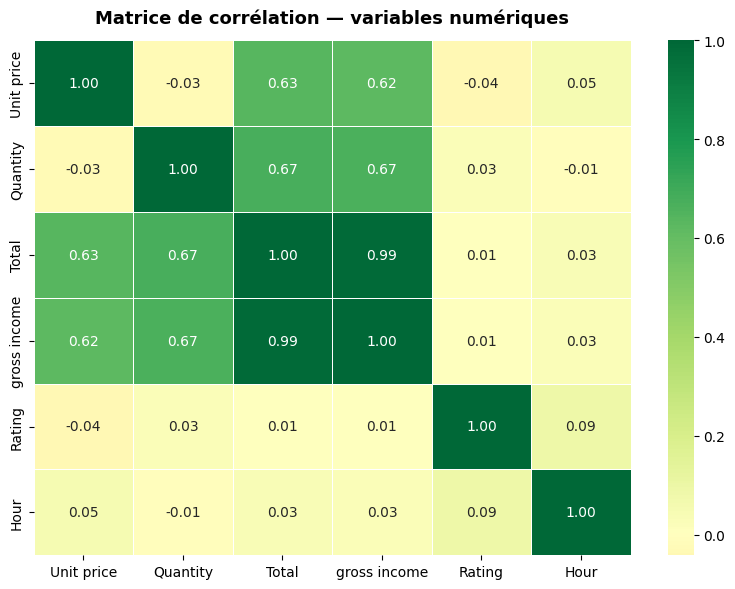

In [10]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(8, 6))
num_cols = ['Unit price','Quantity','Total','gross income','Rating','Hour']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Matrice de corrélation — variables numériques', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('heatmap_correlations.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Étape 6 — Insights & Recommandations

In [12]:
best_cat    = df.groupby('Product line')['Total'].sum().idxmax()
worst_cat   = df.groupby('Product line')['Total'].sum().idxmin()
best_hour   = df.groupby('Hour')['Total'].sum().idxmax()
best_branch = df.groupby('Branch')['Total'].sum().idxmax()
best_pay    = df['Payment'].value_counts().idxmax()
member_avg  = df[df['Customer type']=='Member']['Total'].mean()
normal_avg  = df[df['Customer type']=='Normal']['Total'].mean()

print("INSIGHTS CLÉS")
print(f"1. Meilleure catégorie  : {best_cat}")
print(f"2. Catégorie la faible  : {worst_cat}")
print(f"3. Heure de pointe      : {best_hour}h00")
print(f"4. Branche leader       : {best_branch}")
print(f"5. Paiement dominant    : {best_pay}")
print(f"6. Panier Members       : ${member_avg:.2f}")
print(f"   Panier Normal        : ${normal_avg:.2f}")

print()
print("RECOMMANDATIONS")
print(f"- Booster les stocks {best_cat} (top CA)")
print(f"- Promotions spéciales autour de {best_hour}h")
print(f"- Programme de fidélité Members a renforcer")
print(f"- Optimiser les terminaux {best_pay}")

INSIGHTS CLÉS
1. Meilleure catégorie  : Fashion accessories
2. Catégorie la faible  : Sports and travel
3. Heure de pointe      : 14h00
4. Branche leader       : Branche A
5. Paiement dominant    : Ewallet
6. Panier Members       : $310.31
   Panier Normal        : $322.62

RECOMMANDATIONS
- Booster les stocks Fashion accessories (top CA)
- Promotions spéciales autour de 14h
- Programme de fidélité Members a renforcer
- Optimiser les terminaux Ewallet


## Ce que j'ai retenu de ce projet

Ce qui m'a le plus frappé, c'est que les données racontent une histoire cohérente
une fois qu'on sait quoi chercher. Le lien entre satisfaction client et montant dépensé
par exemple — intuitivement on s'attend à une corrélation, mais les données disent
le contraire. Ce genre de découverte, c'est exactement pourquoi l'EDA est indispensable
avant de tirer des conclusions.

J'ai aussi réalisé que la partie la plus longue n'est pas de faire les graphiques,
c'est de se poser les bonnes questions en amont. Un graphique sans question derrière
ne sert à rien.

Ce projet m'a permis de travailler l'ensemble de la chaîne : charger et nettoyer
des données réelles, calculer des KPIs qui ont du sens business, visualiser les résultats
de façon lisible, et formuler des recommandations concrètes — pas juste décrire
ce que les graphiques montrent.

---
Réalisé par **BARBARE Lina**